# Tagger Baseado em RNN e LSTM

In [1]:
# 1. Clona o projeto para o ambiente temporário do Colab
!git clone https://github.com/lucasaamorim/NLP

Cloning into 'NLP'...
remote: Enumerating objects: 217, done.
remote: Counting objects: 100% (217/217), done.
remote: Compressing objects: 100% (162/162), done.
remote: Total 217 (delta 84), reused 152 (delta 46), pack-reused 0 (from 0)
Receiving objects: 100% (217/217), 10.81 MiB | 16.75 MiB/s, done.
Resolving deltas: 100% (84/84), done.


In [2]:
# 2. Entra na pasta do projeto
%cd NLP

/content/NLP


In [3]:
# 3. Instala o arquivo de dependências (caso o notebook use algo além do TensorFlow padrão)
!uv pip install keras scikit-learn nltk regex

Using Python 3.12.13 environment at: /usr
Checked 4 packages in 189ms


In [4]:
!wget http://nlp.stanford.edu/data/glove.6B.zip

!unzip glove.6B.zip

--2026-07-09 22:46:12--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-07-09 22:46:12--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-07-09 22:46:12--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [5]:
import numpy as np
import keras
from keras import layers
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

from src.utils.data_loader import load_tagging_data, load_pretrained_embeddings
from src.utils.preprocessing import tokenize_sentences, vectorize_tags, build_embedding_matrix

In [6]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [7]:
%cd /content/drive/MyDrive/pos_tagging_data/data

/content/drive/MyDrive/pos_tagging_data/data


In [8]:
# ln -s /caminho/real/no/drive /content/nome_que_o_codigo_espera
!ln -s "/content/drive/MyDrive/pos_tagging_data/data" "/content/NLP/data"

###Carregando os dados de POS Tagging

In [9]:
data = load_tagging_data()
print("Dados do POS Tagging carregados")

Dados do POS Tagging carregados


###Separando os splits originais

In [10]:
train_sentences = data["train"]["sentences"]
train_tags = data["train"]["tags"]

val_sentences = data["val"]["sentences"]
val_tags = data["val"]["tags"]

test_sentences = data["test"]["sentences"]
test_tags = data["test"]["tags"]

print(f"Sentenças de Treino: {len(train_sentences)} | Validação: {len(val_sentences)} | Teste: {len(test_sentences)}")

Sentenças de Treino: 38219 | Validação: 5527 | Teste: 5462


###Processando o Vocabulário de Palavras

In [11]:
vocab_size = 8000  # Limite máximo de palavras únicas
vectorizer, max_len = tokenize_sentences(train_sentences, vocab_size)

X_train = vectorizer([" ".join(s) for s in train_sentences]).numpy()
X_val = vectorizer([" ".join(s) for s in val_sentences]).numpy()
X_test = vectorizer([" ".join(s) for s in test_sentences]).numpy()

###Processando o Vocabulário de Tags

In [12]:
tag_lookup, Y_train = vectorize_tags(train_tags, max_len)

num_tags = tag_lookup.vocabulary_size()

_, Y_val = vectorize_tags(val_tags, max_len, existing_lookup=tag_lookup)
_, Y_test = vectorize_tags(test_tags, max_len, existing_lookup=tag_lookup)

print(f"Formato final de X_train: {X_train.shape}")
print(f"Formato final de Y_train: {Y_train.shape}")
print(f"Formato final de X_test: {X_test.shape}")
print(f"Formato final de Y_test: {Y_test.shape}")
print(f"Número total de tags (classes): {num_tags}")

Formato final de X_train: (38219, 249)
Formato final de Y_train: (38219, 249)
Formato final de X_test: (5462, 249)
Formato final de Y_test: (5462, 249)
Número total de tags (classes): 47


In [13]:
# Hiperparâmetros
embedding_dim = 50
rnn_units = 128
BATCH_SIZE = 32
EPOCHS = 5
glove_path = f"/content/NLP/data/glove.6B.{embedding_dim}d.txt"

glove_index = load_pretrained_embeddings(glove_path)
embedding_matrix = build_embedding_matrix(vectorizer, glove_index, embedding_dim)

inputs = keras.Input(shape=(max_len,), dtype="int32")

rnn = layers.Embedding(
    input_dim=vectorizer.vocabulary_size(),
    embeddings_initializer=keras.initializers.Constant(embedding_matrix),
    output_dim=embedding_dim,
    trainable=True,
    mask_zero=True
)(inputs)

Embeddings em /content/NLP/data/glove.6B.50d.txt carregados com sucesso

Matriz de Embedding: 7879 tokens encontrados no GloVe | 120 tokens inicializados aleatoriamente.


###Construindo o modelo RNN unidirecional

In [14]:
rnn_unidirecional = layers.SimpleRNN(rnn_units, return_sequences=True)(rnn)

outputs = layers.Dense(num_tags, activation="softmax")(rnn_unidirecional)

rnn_unidirecional_model = keras.Model(inputs, outputs)

rnn_unidirecional_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

rnn_unidirecional_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 249)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 249, 50)   │    400,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 249)       │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn          │ (None, 249, 128)  │     22,912 │ embedding[0][0],  │
│ (SimpleRNN)         │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 249, 47)   │      6,063 │ simple_rnn[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 428,975 (1.64 MB)

 Trainable params: 428,975 (1.64 MB)

 Non-trainable params: 0 (0.00 B)

###Construindo o modelo LSTM unidirecional


In [15]:
lstm_unidirecional = layers.LSTM(rnn_units, return_sequences=True)(rnn)

outputs = layers.Dense(num_tags, activation="softmax")(lstm_unidirecional)

lstm_unidirecional_model = keras.Model(inputs, outputs)

lstm_unidirecional_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

lstm_unidirecional_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 249)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 249, 50)   │    400,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 249)       │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 249, 128)  │     91,648 │ embedding[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 249, 47)   │      6,063 │ lstm[0][0]        │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 497,711 (1.90 MB)

 Trainable params: 497,711 (1.90 MB)

 Non-trainable params: 0 (0.00 B)

###Construindo o modelo RNN bidirecional

In [16]:
rnn_bidirecional = layers.Bidirectional(layers.SimpleRNN(rnn_units, return_sequences=True))(rnn)

outputs = layers.Dense(num_tags, activation="softmax")(rnn_bidirecional)

rnn_bidirecional_model = keras.Model(inputs, outputs)

rnn_bidirecional_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

rnn_bidirecional_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 249)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 249, 50)   │    400,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 249)       │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 249, 256)  │     45,824 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 249, 47)   │     12,079 │ bidirectional[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 457,903 (1.75 MB)

 Trainable params: 457,903 (1.75 MB)

 Non-trainable params: 0 (0.00 B)

###Construindo o modelo LSTM Bidirecional

In [17]:
# RNN Bidirecional para capturar contexto tanto da esquerda-para-direita quanto da direita-para-esquerda
lstm_bidirecional = layers.Bidirectional(layers.LSTM(rnn_units, return_sequences=True))(rnn)

# Camada densa distribuída no tempo (computa uma distribuição de probabilidade por palavra)
outputs = layers.Dense(num_tags, activation="softmax")(lstm_bidirecional)

lstm_bidirecional_model = keras.Model(inputs, outputs)

# Usamos SparseCategoricalCrossentropy porque nosso Y contém IDs inteiros (não one-hot vectors)
lstm_bidirecional_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

lstm_bidirecional_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 249)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 249, 50)   │    400,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 249)       │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 249, 256)  │    183,296 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 249, 47)   │     12,079 │ bidirectional_1[… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 595,375 (2.27 MB)

 Trainable params: 595,375 (2.27 MB)

 Non-trainable params: 0 (0.00 B)

### Treinamento da RNN Unidirecional

In [18]:
history = rnn_unidirecional_model.fit(
    X_train,
    Y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, Y_val)
)

Epoch 1/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 33s 25ms/step - accuracy: 0.8396 - loss: 0.5718 - val_accuracy: 0.9122 - val_loss: 0.2767
Epoch 2/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 26s 22ms/step - accuracy: 0.9234 - loss: 0.2305 - val_accuracy: 0.9192 - val_loss: 0.2401
Epoch 3/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accuracy: 0.9299 - loss: 0.2025 - val_accuracy: 0.9218 - val_loss: 0.2311
Epoch 4/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 26s 21ms/step - accuracy: 0.9339 - loss: 0.1895 - val_accuracy: 0.9235 - val_loss: 0.2241
Epoch 5/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 26s 22ms/step - accuracy: 0.9365 - loss: 0.1800 - val_accuracy: 0.9239 - val_loss: 0.2232


### Treinamento da LSTM Unidirecional

In [19]:
history = lstm_unidirecional_model.fit(
    X_train,
    Y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, Y_val)
)

Epoch 1/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.8886 - loss: 0.4137 - val_accuracy: 0.9198 - val_loss: 0.2372
Epoch 2/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.9329 - loss: 0.1920 - val_accuracy: 0.9235 - val_loss: 0.2218
Epoch 3/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.9370 - loss: 0.1781 - val_accuracy: 0.9250 - val_loss: 0.2193
Epoch 4/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.9401 - loss: 0.1690 - val_accuracy: 0.9263 - val_loss: 0.2175
Epoch 5/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.9425 - loss: 0.1617 - val_accuracy: 0.9265 - val_loss: 0.2165


### Treinamento da RNN Bidirecional

In [20]:
history = rnn_bidirecional_model.fit(
    X_train,
    Y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, Y_val)
)

Epoch 1/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 58s 44ms/step - accuracy: 0.9254 - loss: 0.2579 - val_accuracy: 0.9369 - val_loss: 0.1905
Epoch 2/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 48s 40ms/step - accuracy: 0.9505 - loss: 0.1452 - val_accuracy: 0.9400 - val_loss: 0.1813
Epoch 3/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 49s 41ms/step - accuracy: 0.9546 - loss: 0.1322 - val_accuracy: 0.9419 - val_loss: 0.1780
Epoch 4/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 48s 40ms/step - accuracy: 0.9575 - loss: 0.1234 - val_accuracy: 0.9396 - val_loss: 0.1870
Epoch 5/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 48s 40ms/step - accuracy: 0.9599 - loss: 0.1158 - val_accuracy: 0.9415 - val_loss: 0.1825


### Treinamento da LSTM Bidirecional

In [21]:
history = lstm_bidirecional_model.fit(
    X_train,
    Y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, Y_val)
)

Epoch 1/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.9240 - loss: 0.2728 - val_accuracy: 0.9401 - val_loss: 0.1817
Epoch 2/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 0.9556 - loss: 0.1298 - val_accuracy: 0.9429 - val_loss: 0.1751
Epoch 3/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 0.9594 - loss: 0.1172 - val_accuracy: 0.9441 - val_loss: 0.1710
Epoch 4/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.9626 - loss: 0.1079 - val_accuracy: 0.9438 - val_loss: 0.1723
Epoch 5/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 0.9653 - loss: 0.0999 - val_accuracy: 0.9433 - val_loss: 0.1797


###Função de Avaliação dos modelos

In [22]:
def model_evaluation(model, X_test, Y_test, tag_lookup, model_name):
    # 1. Predict probabilities for each class per word
    predictions_prob = model.predict(X_test)

    # 2. Get the index of the class with the highest probability
    predicted_classes = np.argmax(predictions_prob, axis=-1)

    y_true_filtered = []
    y_pred_filtered = []

    # 3. Filter data by removing ID 0 (<PAD>)
    for i in range(len(Y_test)):
        for j in range(len(Y_test[i])):
            if Y_test[i][j] != 0:  # 0 is the <PAD> ID generated by StringLookup
                y_true_filtered.append(Y_test[i][j])
                y_pred_filtered.append(predicted_classes[i][j])

    # 4. Get the actual vocabulary from your tag_lookup
    full_vocabulary = tag_lookup.get_vocabulary()

    # Find which unique IDs actually remain in y_true
    present_ids = sorted(list(set(y_true_filtered)))

    # --- CORREÇÃO DO JJ E DA ORDEM ALFABÉTICA ---
    # Criamos pares de (Nome único com ID, ID original) para mapear sem duplicar no gráfico
    tag_pairs = []
    for idx in present_ids:
        tag_name = full_vocabulary[int(idx)]
        # Adiciona o ID ao nome (Resolve o problema do JJ duplicado)
        unique_name = f"{tag_name}"
        tag_pairs.append((unique_name, idx))

    # Ordena a lista de tuplas em ordem alfabética pelo nome da tag
    tag_pairs_sorted = sorted(tag_pairs, key=lambda x: x[0])

    # Separamos de volta os nomes ordenados alfabeticamente e a ordem dos IDs correspondentes
    alphabetical_names = [pair[0] for pair in tag_pairs_sorted]
    alphabetical_ids = [pair[1] for pair in tag_pairs_sorted]

    print("\n" + "="*50)
    print("Classification Report Without Padding")
    print("="*50)
    # No relatório de texto, usamos a ordem alfabética mapeando os nomes limpos (sem o sufixo do ID para o relatório ficar bonito)
    clean_alphabetical_names = [full_vocabulary[int(idx)] for idx in alphabetical_ids]
    print(classification_report(y_true_filtered, y_pred_filtered, labels=alphabetical_ids, target_names=clean_alphabetical_names, zero_division=0))

    # 5. Confusion Matrix alinhada com a nova ordem alfabética
    cm = confusion_matrix(y_true_filtered, y_pred_filtered, labels=alphabetical_ids)

    with np.errstate(all='ignore'):
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        cm_normalized = np.nan_to_num(cm_normalized)

    # Aumentamos um pouco o tamanho para acomodar os espaçamentos retos das palavras
    plt.figure(figsize=(18, 14))

    # Renderiza a matriz normalizada usando os nomes em ordem alfabética e com IDs únicos
    ax = sns.heatmap(cm_normalized, annot=False, cmap="Blues", vmin=0.0, vmax=1.0,
                xticklabels=alphabetical_names, yticklabels=alphabetical_names)

    # --- CORREÇÃO DO ESPAÇAMENTO SEM ROTACIONAR ---
    ax.tick_params(axis='x', rotation=90, labelsize=10, pad=12)
    ax.tick_params(axis='y', rotation=0, labelsize=10, pad=12)

    plt.title(f"Matriz de Confusão (Normalizada) - {model_name}", fontsize=14, pad=25)
    plt.xlabel("Predito", fontsize=12, labelpad=20) # Aumentado o recuo do título do eixo X
    plt.ylabel("Real", fontsize=12, labelpad=20)    # Aumentado o recuo do título do eixo Y

    plt.tight_layout()
    plt.show()

### Avaliação da RNN Unidirecional

171/171 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step

Classification Report Without Padding
              precision    recall  f1-score   support

           #       1.00      1.00      1.00        15
           $       1.00      0.99      1.00       943
          ''       1.00      0.99      1.00      1045
           ,       1.00      1.00      1.00      6876
       -LRB-       1.00      1.00      1.00       186
       -RRB-       1.00      1.00      1.00       187
           .       1.00      1.00      1.00      5381
           :       1.00      1.00      1.00       752
          CC       1.00      0.99      0.99      3250
          CD       0.99      0.89      0.94      4823
          DT       0.97      1.00      0.98     11183
          EX       0.97      0.49      0.65       126
          FW       0.25      0.07      0.11        30
          IN       0.94      0.98      0.96     13492
          JJ       0.66      0.85      0.74      8215
         JJR       0.78      0.66      0.72       423


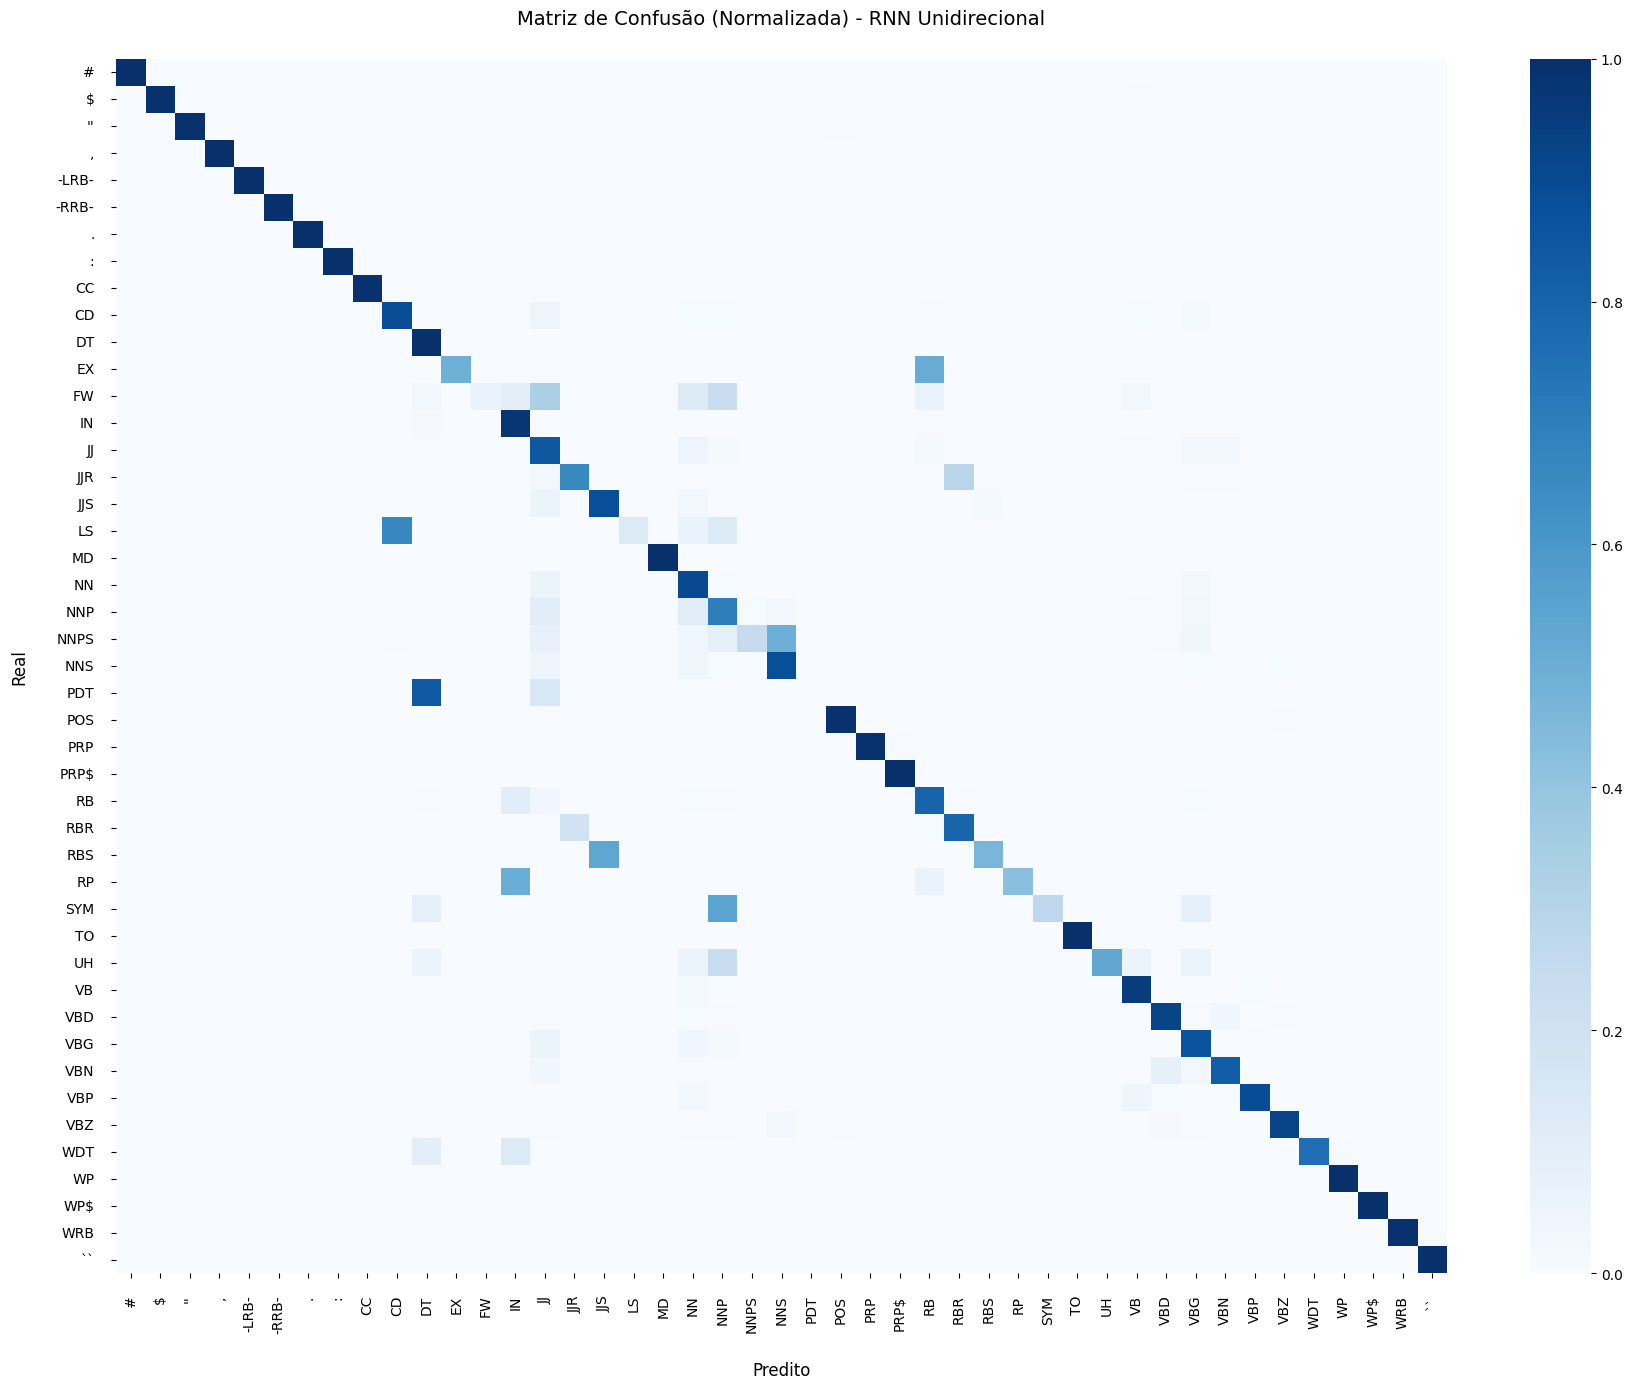

In [23]:
model_evaluation(rnn_unidirecional_model, X_test, Y_test, tag_lookup, "RNN Unidirecional")

### Avaliação da LSTM Unidirecional

171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

Classification Report Without Padding
              precision    recall  f1-score   support

           #       1.00      1.00      1.00        15
           $       1.00      0.99      1.00       943
          ''       1.00      1.00      1.00      1045
           ,       1.00      1.00      1.00      6876
       -LRB-       1.00      1.00      1.00       186
       -RRB-       1.00      1.00      1.00       187
           .       1.00      1.00      1.00      5381
           :       1.00      1.00      1.00       752
          CC       0.99      0.99      0.99      3250
          CD       0.98      0.93      0.96      4823
          DT       0.99      0.99      0.99     11183
          EX       0.96      0.85      0.90       126
          FW       0.27      0.10      0.15        30
          IN       0.95      0.98      0.97     13492
          JJ       0.69      0.86      0.76      8215
         JJR       0.74      0.87      0.80       423
 

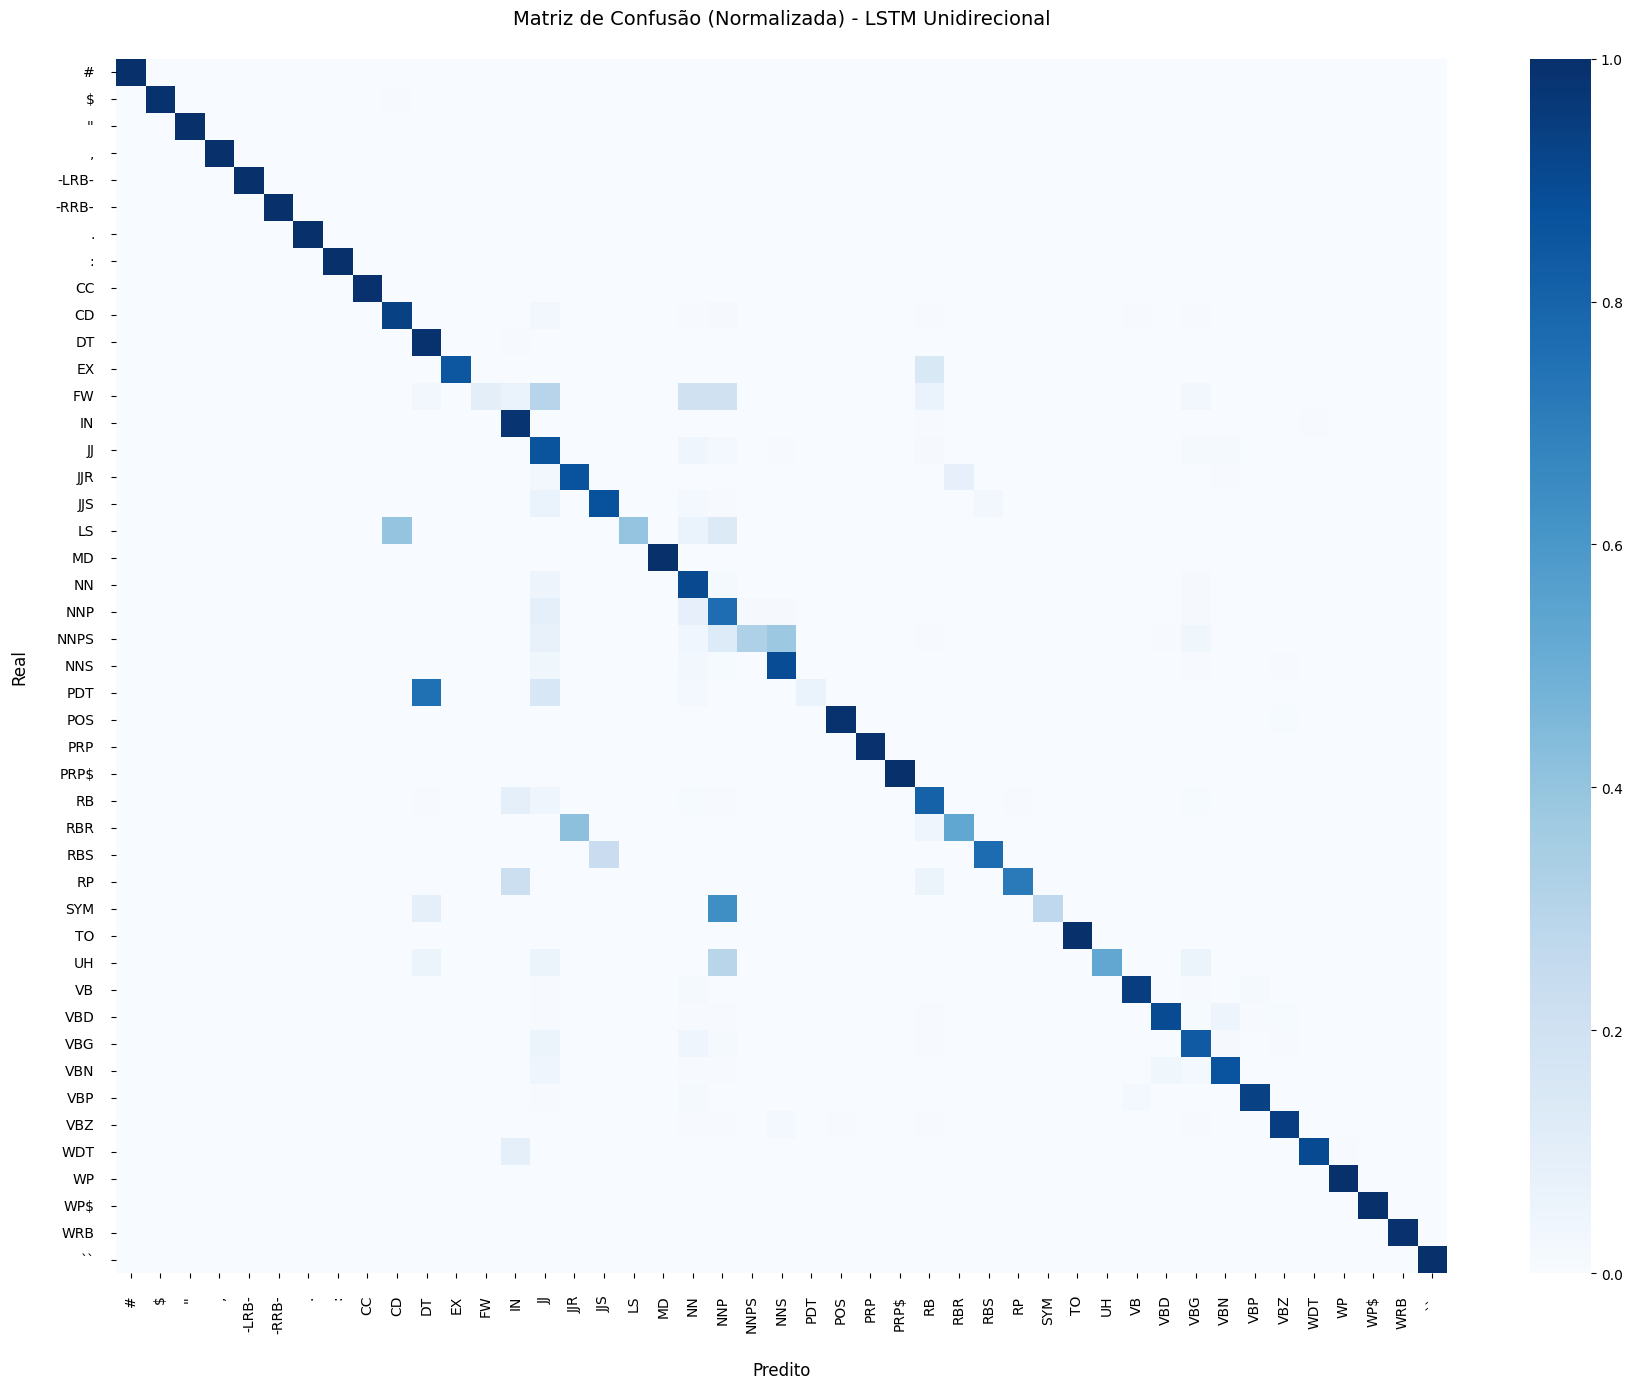

In [24]:
model_evaluation(lstm_unidirecional_model, X_test, Y_test, tag_lookup, "LSTM Unidirecional")

### Avaliação da RNN Bidirecional

171/171 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step

Classification Report Without Padding
              precision    recall  f1-score   support

           #       1.00      1.00      1.00        15
           $       1.00      0.99      1.00       943
          ''       0.99      1.00      1.00      1045
           ,       1.00      1.00      1.00      6876
       -LRB-       1.00      1.00      1.00       186
       -RRB-       1.00      1.00      1.00       187
           .       1.00      1.00      1.00      5381
           :       1.00      1.00      1.00       752
          CC       1.00      1.00      1.00      3250
          CD       0.95      0.98      0.97      4823
          DT       1.00      0.99      0.99     11183
          EX       0.94      1.00      0.97       126
          FW       0.36      0.13      0.20        30
          IN       0.96      0.99      0.97     13492
          JJ       0.83      0.89      0.86      8215
         JJR       0.88      0.81      0.84       423


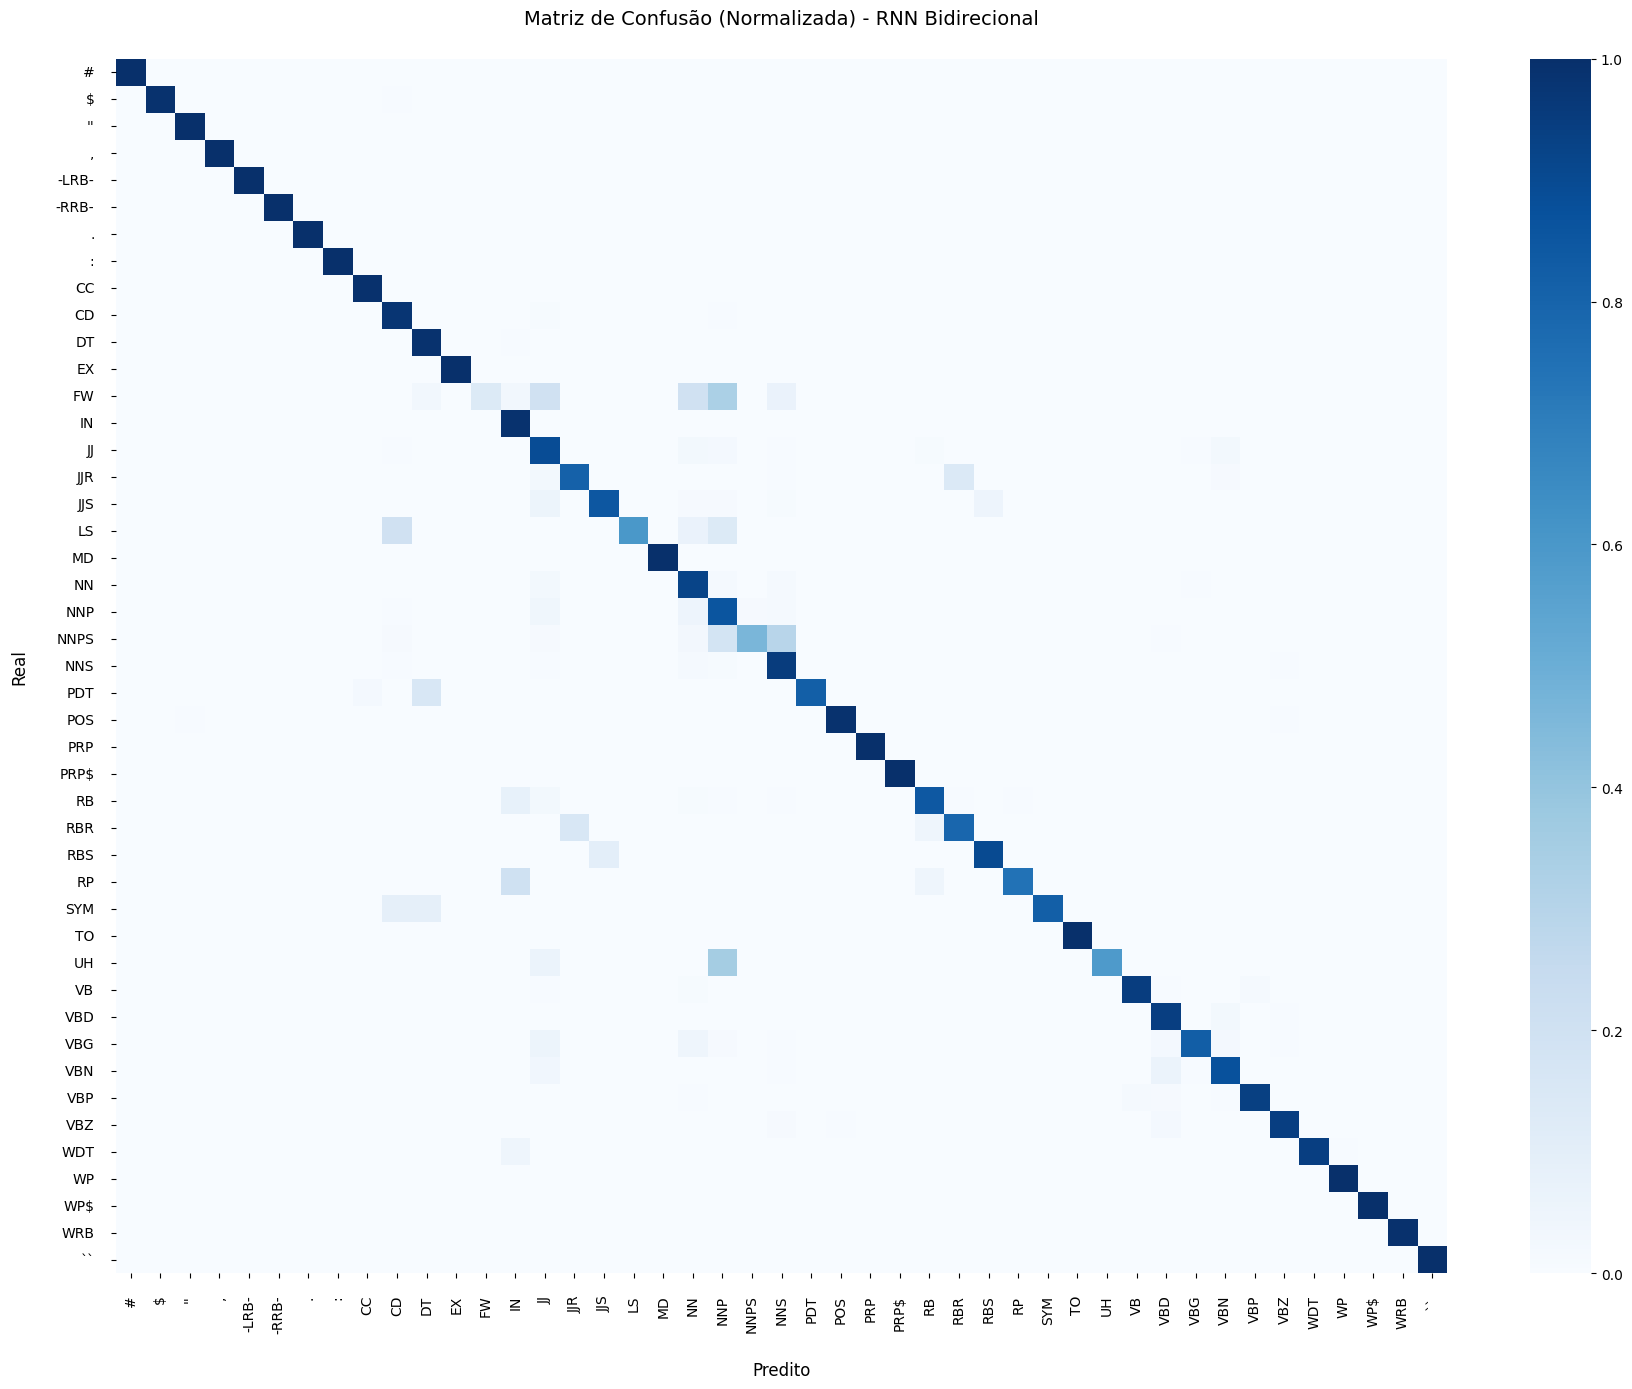

In [25]:
model_evaluation(rnn_bidirecional_model, X_test, Y_test, tag_lookup, "RNN Bidirecional")

### Avaliação da LSTM Bidirecional

171/171 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step

Classification Report Without Padding
              precision    recall  f1-score   support

           #       1.00      1.00      1.00        15
           $       1.00      0.99      1.00       943
          ''       1.00      1.00      1.00      1045
           ,       1.00      1.00      1.00      6876
       -LRB-       1.00      1.00      1.00       186
       -RRB-       1.00      1.00      1.00       187
           .       1.00      1.00      1.00      5381
           :       1.00      1.00      1.00       752
          CC       1.00      1.00      1.00      3250
          CD       0.97      0.98      0.97      4823
          DT       1.00      0.99      0.99     11183
          EX       0.96      1.00      0.98       126
          FW       0.42      0.17      0.24        30
          IN       0.98      0.98      0.98     13492
          JJ       0.85      0.87      0.86      8215
         JJR       0.86      0.83      0.85       423
 

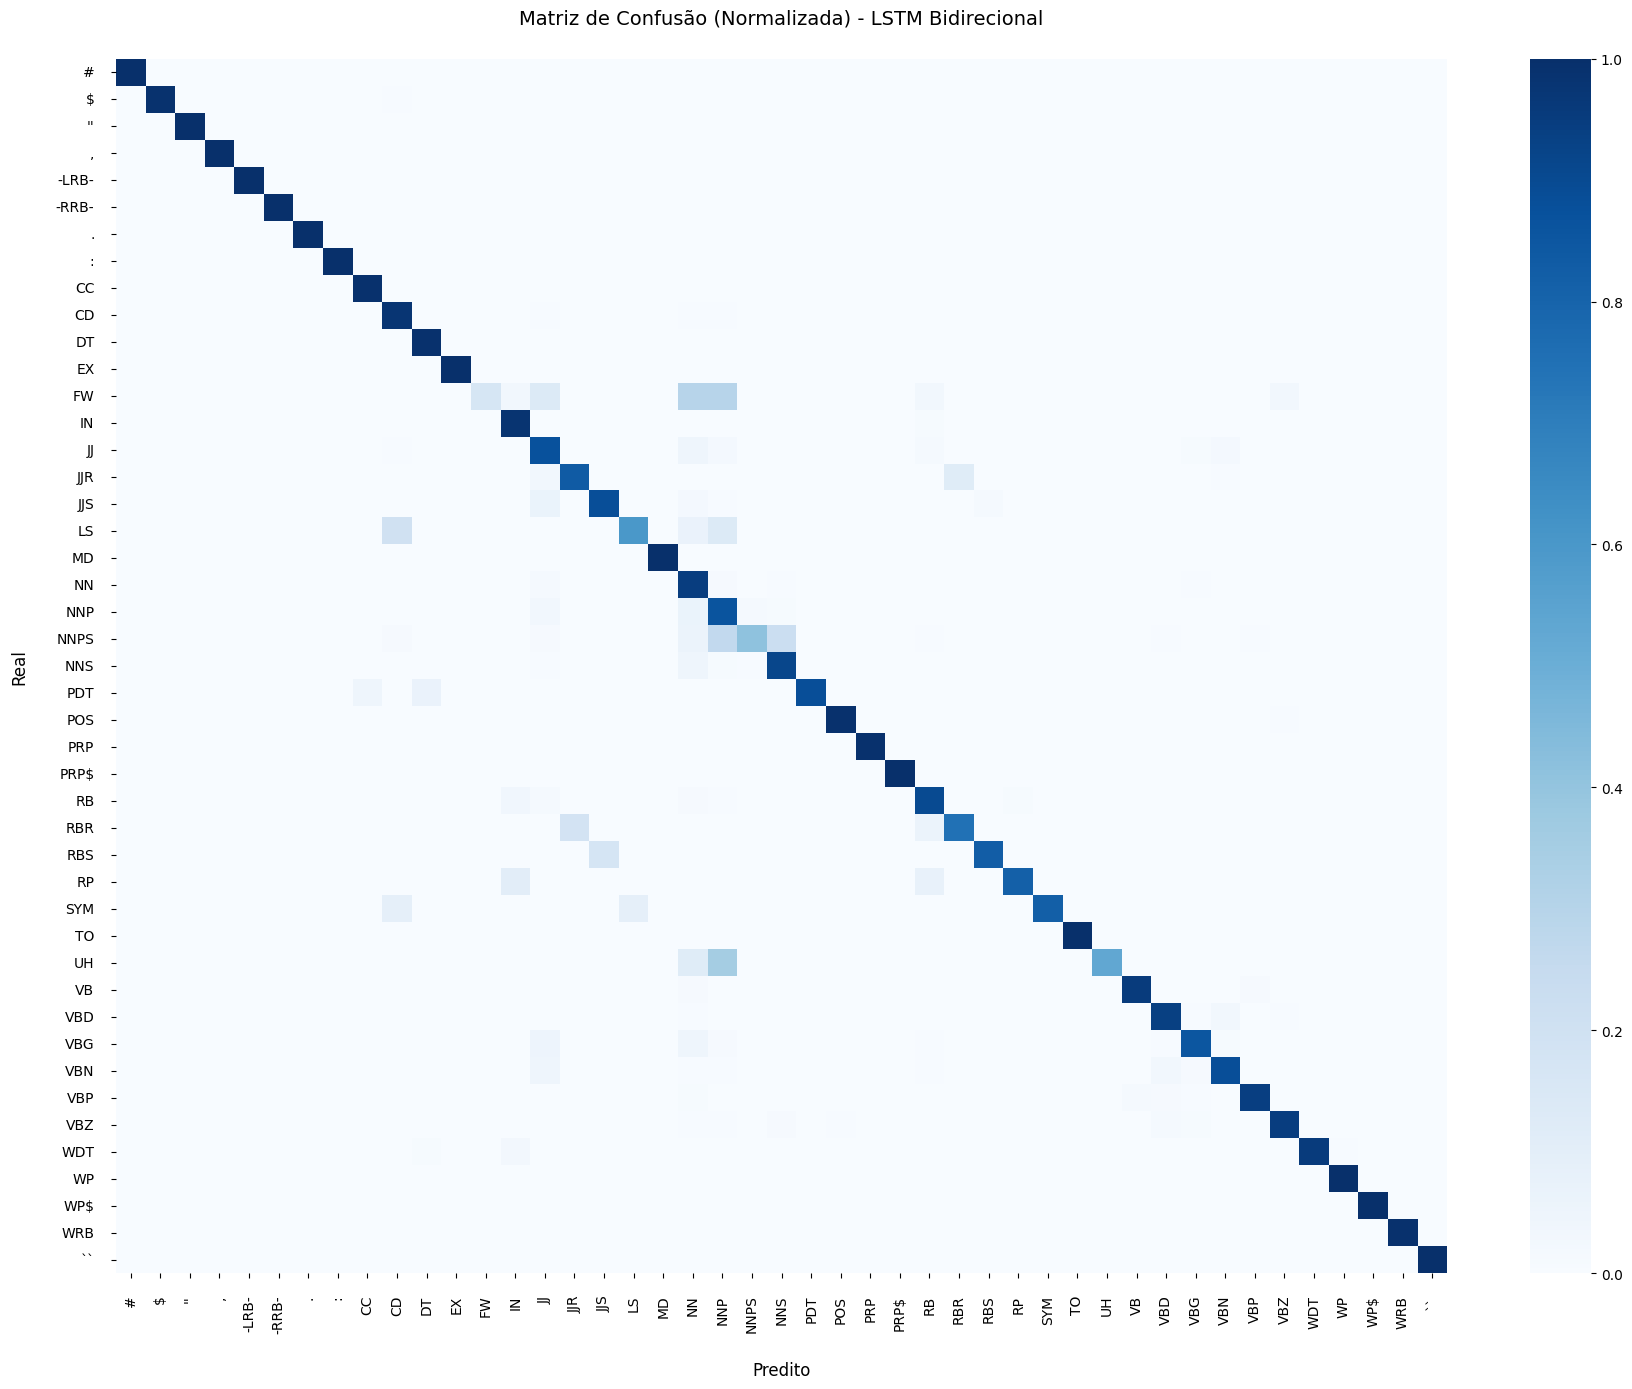

In [26]:
model_evaluation(lstm_bidirecional_model, X_test, Y_test, tag_lookup, "LSTM Bidirecional")